In [2]:
!pip install -q -U diffusers transformers accelerate safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 25.6 MB/s eta 0:00:00


In [3]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

device = "cuda"if torch.cuda.is_available()else"cpu"
print("device :",device)

device : cuda


In [4]:
model_id="stable-diffusion-v1-5/stable-diffusion-v1-5"

pipe=StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    use_safetensors=True,

)
pipe = pipe.to(device)
print("Stable Diffusion Loaded ")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Stable Diffusion Loaded 


  0%|          | 0/200 [00:00<?, ?it/s]

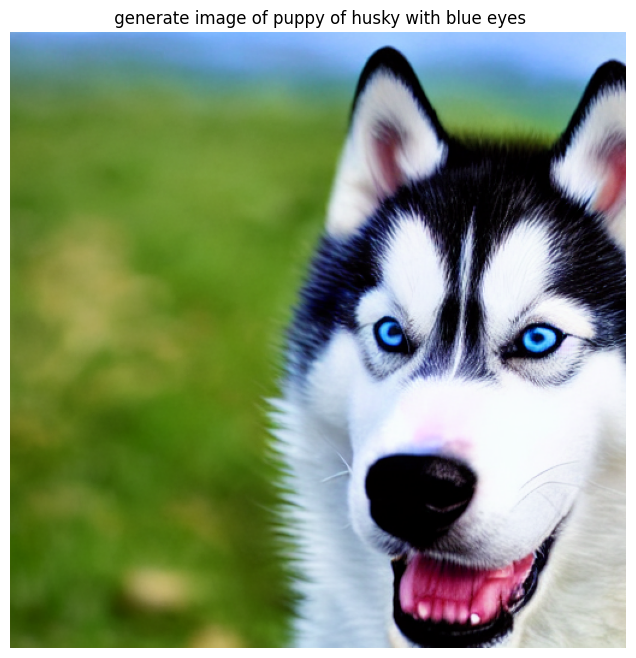

In [16]:
prompt = " generate image of puppy of husky with blue eyes"

result=pipe(
    prompt,
    num_inference_steps=200,
    guidance_scale=7.5,

)

image = result.images[0]

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.title(prompt)
plt.show()